<a href="https://colab.research.google.com/github/bigw1030/IST387final/blob/main/Predicting_E_Commerce_Sales_for_Targeted_Marketing_and_Customer_Service_Efforts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
! pip install pyspark

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

In [ ]:
# Create Spark Session
spark = (SparkSession.builder
  .appName('Economics-Project')
  # allocates 8 gigabytes (8g) of RAM to the Spark driver, More memory = can handle bigger datasets
  .config("spark.driver.memory", "8g")
  .getOrCreate() # Gets - an existing Spar Session if one is already running | - Creates - a new Spark Session if none exists
)
print("Spark Session created")

Spark Session created


In [ ]:
from google.colab import drive
import shutil
import os

# Mount Google Drive
drive.mount('/content/drive')

# Paths
drive_folder = '/content/drive/MyDrive/IST418_Project_Data/'
local_folder = '/kaggle/working/'

# Check if data exists in Google Drive
if os.path.exists(drive_folder):
    print("📂 Found data in Google Drive!")
    print("📥 Copying data from Google Drive to local storage (one-time setup)...\n")

    # List of parquet directories to copy
    items = [
        'purchases.parquet',
        'top_categories.parquet',
        'cluster_profiles.parquet',
        'revenue_analysis.parquet',
        'ecommerce_df.parquet',
        'rfm_segments.parquet',
        'rfm.parquet'
    ]

    for item in items:
        src = os.path.join(drive_folder, item)
        dst = os.path.join(local_folder, item)

        if os.path.exists(src):
            print(f"  Copying {item}...")

            # REMOVE existing destination if it exists
            if os.path.exists(dst):
                shutil.rmtree(dst)

            # Now copy
            shutil.copytree(src, dst)

    print("\n✅ Copy complete!\n")
else:
    print("❌ Data not found in Google Drive!")
    print(f"Expected location: {drive_folder}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Found data in Google Drive!
📥 Copying data from Google Drive to local storage (one-time setup)...

  Copying purchases.parquet...
  Copying top_categories.parquet...
  Copying cluster_profiles.parquet...
  Copying revenue_analysis.parquet...
  Copying ecommerce_df.parquet...
  Copying rfm_segments.parquet...
  Copying rfm.parquet...

✅ Copy complete!



In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

# Initialize Spark
spark = SparkSession.builder \
    .appName("E-commerce Analysis") \
    .getOrCreate()

# Load the data
print("Loading data...")
purchases = spark.read.parquet('/kaggle/working/purchases.parquet')
ecommerce_df = spark.read.parquet('/kaggle/working/ecommerce_df.parquet')
rfm = spark.read.parquet('/kaggle/working/rfm.parquet')
rfm_segments = spark.read.parquet('/kaggle/working/rfm_segments.parquet')

print(f"Purchases: {purchases.count():,} rows")
print(f"RFM: {rfm.count():,} rows")

📥 Loading data...
✅ Purchases: 1,659,788 rows
✅ RFM: 697,470 rows


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mkechinov/ecommerce-behavior-data-from-multi-category-store")

print("Path to dataset files:", path)

100%|██████████| 4.29G/4.29G [00:50<00:00, 90.9MB/s]

Extracting files...


In [ ]:
ecommerce_df = spark.read.csv(
    path,
    header=True,
    inferSchema=True
)

In [ ]:
ecommerce_df.show(5)

In [ ]:
print(ecommerce_df.columns)

In [ ]:
# Count rows where brand is NULL/missing
null_brand_count = ecommerce_df.filter(F.col("brand").isNull()).count()
print(f"Rows with missing brand: {null_brand_count:,}")

In [ ]:
# Fill NULL brands with "Unknown"
ecommerce_df = ecommerce_df.fillna({"brand": "Unknown"})

# Verify
unknown_count = ecommerce_df.filter(F.col("brand") == "Unknown").count()
print(f"Rows now with 'Unknown' brand: {unknown_count:,}")

In [ ]:
# only care about actual purchases for RFM (Recency Frequency Monetary)
# Rencey - How recently did the customer purhcase? (Lower is better; more recent = more engaged)
# Frequency - How often does the custome purhcase? Measured as number of purchases; (Higher is better; Frequency buyer = loyal customer)
# Monetary - Measured as total amount spent (Higher is better)

In [ ]:
# filters to purchases only
purchases = ecommerce_df.filter(F.col("event_type") == "purchase")
print(f"Found {purchases.count():,} purchases")

NameError: name 'ecommerce_df' is not defined

In [ ]:
# RFM features per user
max_date = purchases.agg(F.max("event_time")).collect()[0][0]
ref_date = F.lit(max_date) + F.expr("INTERVAL 1 DAY")

rfm = (
    purchases
    .groupBy("user_id")
    .agg(
        F.datediff(ref_date, F.max("event_time")).alias("recency"),
        F.count("*").alias("frequency"),
        F.round(F.sum("price"), 2).alias("monetary"),
    )
    .cache()   # cache — reused in threshold calc + pipeline
)

print("RFM sample (5 rows):")
rfm.show(5)
print(f"Total users with purchases: {rfm.count():,}")

RFM sample (5 rows):
+---------+-------+---------+--------+
|  user_id|recency|frequency|monetary|
+---------+-------+---------+--------+
|546839974|     27|       11| 1371.48|
|555468492|     61|        1|  167.21|
|518619616|     61|        4|  611.08|
|537163771|     38|        4| 1911.41|
|540805815|     17|        7| 1491.91|
+---------+-------+---------+--------+
only showing top 5 rows
Total users with purchases: 697,470


In this cell, we prep for clustering. To do this, we built a Spark ML Pipeline, chaining a VectorAssembler, which combines the three RFM columns into a single feature vector, with a StandardScaler, which normalizes the values so no single feature dominates just because of its scale.

In [ ]:

from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler

assembler = VectorAssembler(
    inputCols=["recency", "frequency", "monetary"],
    outputCol="features_raw"
)

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withMean=True,
    withStd=True
)

pipeline = Pipeline(stages=[assembler, scaler])
pipeline_model = pipeline.fit(rfm)
rfm_scaled = pipeline_model.transform(rfm)

For picking the number of clusters, we ran K-Means across k values 2 through 7 on a 5% sample of the data and scored each one using the score, a metric that measures how well-separated the clusters are. The best k got used for the final model.

In [ ]:
# choosing k value

from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

sample_fraction = 0.05

prep_pipeline = Pipeline(stages=[assembler, scaler]).fit(rfm)
rfm_scaled_full = prep_pipeline.transform(rfm).cache()

rfm_sample = rfm_scaled_full.sample(fraction=sample_fraction, seed=42).cache()
print(f"Sample size for k-selection: {rfm_sample.count():,} users")

evaluator = ClusteringEvaluator(featuresCol="features", metricName="silhouette")

scores = {}
for k in range(2, 8):
    km = KMeans(featuresCol="features", k=k, seed=42, maxIter=20)
    model = km.fit(rfm_sample)
    preds = model.transform(rfm_sample)
    score = evaluator.evaluate(preds)
    scores[k] = score
    print(f"  k={k}  silhouette={score:.4f}")

rfm_sample.unpersist()

best_k = max(scores, key= scores.get)
print(f"Best k = {best_k}  (silhouette = {scores[best_k]:.4f})")


Sample size for k-selection: 34,977 users
  k=2  silhouette=0.1803
  k=3  silhouette=0.4713
  k=4  silhouette=0.5074
  k=5  silhouette=0.7016
  k=6  silhouette=0.7352
  k=7  silhouette=0.5306
Best k = 6  (silhouette = 0.7352)


In this cell, we create the final k means values.

In [ ]:
km_final = KMeans(featuresCol="features", k=6, seed=42, maxIter=20)
km_model  = km_final.fit(rfm_scaled)
rfm_clustered = km_model.transform(rfm_scaled)

The following cell simply gives us an idea of the data distribution, which helped direct our future analysis.

In [ ]:
med_rec = rfm.approxQuantile("recency", [0.5], 0.01)[0]
med_frq = rfm.approxQuantile("frequency", [0.75], 0.01)[0]
med_mon = rfm.approxQuantile("monetary", [0.75], 0.01)[0]

print(f"Thresholds:")
print(f"  Median Recency:   {med_rec} days")
print(f"  Median Frequency: {med_frq} purchases")
print(f"  Median Monetary:  ${med_mon:.2f}")

Thresholds:
  Median Recency:   21.0 days
  Median Frequency: 2.0 purchases
  Median Monetary:  $643.23


We summarized each cluster by computing the average recency, frequency, and monetary values for the users inside it using groupBy and agg. Then we calculated population-level thresholds using approxQuantile. We used the median for recency and the 75th percentile for frequency and spend, so that "high frequency" and "high monetary" actually mean something, representing the top 25% of customers rather than just the average. The assign_segment function is just if/elif rules that map each cluster's RFM averages to labels like "VIP" or "At-Risk" based the thresholds. It uses three boolean flags, low_rec, hi_frq, hi_mon. To label every user row in Spark, we used F.create_map to assign the labels across the cluster rather than row-by-row. Finally, withColumn applies that map to tag every user with their segment.

In [ ]:
# Calculate thresholds - use 75th percentile for frequency and monetary
med_rec = rfm.approxQuantile("recency", [0.5], 0.01)[0]      # Median for recency
p75_frq = rfm.approxQuantile("frequency", [0.75], 0.01)[0]   # 75th percentile
p75_mon = rfm.approxQuantile("monetary", [0.75], 0.01)[0]    # 75th percentile

print(f"\nThresholds:")
print(f"  Median Recency: {med_rec} days")
print(f"  75th %ile Frequency: {p75_frq} purchases")
print(f"  75th %ile Monetary: ${p75_mon:.2f}")

# Collect cluster profiles to a local dict so we can label each cluster
profiles = {
    row["prediction"]: row
    for row in cluster_profile.collect()
}

def assign_segment(avg_rec, avg_frq, avg_mon):
    """E-commerce specific segment names based on shopping behavior"""

    # Define thresholds
    low_rec = avg_rec <= med_rec      # Purchased recently
    hi_frq = avg_frq > p75_frq         # High frequency (top 25%)
    hi_mon = avg_mon > p75_mon         # High monetary (top 25%)

    # E-commerce segments
3

cluster_label_map = {
    0: "First-Time Shoppers",      # rec=14.0, freq=1.78, mon=$441
    1: "Repeat Buyers",             # rec=14.2, freq=8.83, mon=$3,304
    2: "Bulk Purchasers",           # rec=6.8, freq=172.33, mon=$119,637 (!!!)
    3: "One-and-Done",              # rec=45.1, freq=1.55, mon=$410
    4: "Premium Shoppers",          # rec=12.1, freq=26.63, mon=$11,138
    5: "Brand Loyalists"            # rec=9.9, freq=67.27, mon=$34,970
}

print("Cluster → E-Commerce Segment mapping:")
for cid, seg in sorted(cluster_label_map.items()):
    p = profiles[cid]
    print(f"  Cluster {cid}: {seg:25s} "
          f"(rec={p['avg_recency']:.1f} "
          f"freq={p['avg_frequency']:.2f} "
          f"mon=${p['avg_monetary']:.2f} "
          f"n={p['num_users']:,} users)")

# Apply segment labels back to every user row
label_expr = F.create_map(
    [F.lit(x) for cid, seg in cluster_label_map.items()
     for x in [cid, seg]]
)

rfm_final = (
    rfm_clustered
    .withColumn("segment", label_expr[F.col("prediction")])
    .select("user_id", "recency", "frequency", "monetary", "prediction", "segment")
)

print("Final RFM table sample:")
rfm_final.show(10, truncate=False)

# Verify segment distribution
print("E-Commerce Segment Distribution:")
rfm_final.groupBy("segment").count().orderBy(F.desc("count")).show()

In [ ]:
from pyspark.errors.utils import with_origin_to_class
# Verify segment distribution with percentages
segment_summary = (
    rfm_final
    .groupBy("segment")
    .agg(
        F.count("*").alias("customer_count")
    )
    .withColumn(
        "percentage",
        F.round(F.col("customer_count") / F.sum("customer_count").over(Window.partitionBy())* 100,2)
    )
    .orderBy(F.desc("customer_count"))
)

print("\n=== Segment Distribution ===")
segment_summary.show()


=== Segment Distribution ===
+-------------------+--------------+----------+
|            segment|customer_count|percentage|
+-------------------+--------------+----------+
|First-Time Shoppers|        392643|      56.3|
|       One-and-Done|        258750|      37.1|
|      Repeat Buyers|         39659|      5.69|
|   Premium Shoppers|          5678|      0.81|
|    Brand Loyalists|           674|       0.1|
|    Bulk Purchasers|            66|      0.01|
+-------------------+--------------+----------+



In [ ]:
# Revenue Analysis - "Which segments drive the most revenue?"
from pyspark.sql import Window

revenue_analysis = (
    rfm_final
    .groupBy("segment")
    .agg(
        F.count("*").alias("customer_count"),
        F.sum("monetary").alias("total_revenue"),
        F.round(F.mean("monetary"), 2).alias("avg_revenue_per_customer"),
        F.round(F.min("monetary"), 2).alias("min_revenue"),
        F.round(F.max("monetary"), 2).alias("max_revenue")
    )
    .withColumn(
        "revenue_percentage",
        F.round(F.col("total_revenue") / F.sum("total_revenue").over(Window.partitionBy()) * 100, 2)
    )
    .orderBy(F.desc("total_revenue"))
)

print("=== Revenue Analysis by Segment ===")  # fixed: removed the "n\=" typo
revenue_analysis.show()

=== Revenue Analysis by Segment ===
+-------------------+--------------+--------------------+------------------------+-----------+-----------+------------------+
|            segment|customer_count|       total_revenue|avg_revenue_per_customer|min_revenue|max_revenue|revenue_percentage|
+-------------------+--------------+--------------------+------------------------+-----------+-----------+------------------+
|First-Time Shoppers|        392643|1.7323548386999992E8|                   441.2|       0.77|    4015.29|             34.29|
|      Repeat Buyers|         39659|1.3104856811999996E8|                 3304.38|      30.82|   13420.05|             25.94|
|       One-and-Done|        258750|1.0615922032000001E8|                  410.28|       0.88|    6861.17|             21.02|
|   Premium Shoppers|          5678| 6.324295212999998E7|                11138.24|      664.3|   34418.55|             12.52|
|    Brand Loyalists|           674|       2.357012262E7|                34970.51|

In [ ]:
# Product Category Analysis

# join purchases with segments
segment_purchases = (
    purchases
    .join(rfm_final.select("user_id", "segment"), on="user_id")
    .select("segment", "category_code", "brand", "price")
)

# Top 5 Categories per segment
top_categories = (
    segment_purchases
    .filter(F.col("category_code").isNotNull())
    .groupBy("segment", "category_code")
    .agg(
        F.count("*").alias("purchase_count"),
        F.round(F.sum("price"), 2).alias("revenue")
    )
    .withColumn("rank", F.row_number().over(
        Window.partitionBy("segment").orderBy(F.desc("purchase_count"))
    ))
    .filter(F.col("rank")<= 5)
    .orderBy("segment", "rank")
)

print("\n=== Top 5 Categories per Segment ===")
top_categories.show(50, truncate=False)


=== Top 5 Categories per Segment ===
+-------------------+-----------------------------+--------------+--------------+----+
|segment            |category_code                |purchase_count|revenue       |rank|
+-------------------+-----------------------------+--------------+--------------+----+
|Brand Loyalists    |electronics.smartphone       |28617         |1.837197555E7 |1   |
|Brand Loyalists    |electronics.audio.headphone  |1423          |207501.55     |2   |
|Brand Loyalists    |electronics.clocks           |1386          |507891.96     |3   |
|Brand Loyalists    |computers.notebook           |1367          |1138310.49    |4   |
|Brand Loyalists    |electronics.video.tv         |1316          |545364.99     |5   |
|Bulk Purchasers    |electronics.smartphone       |8674          |6503976.9     |1   |
|Bulk Purchasers    |electronics.video.tv         |431           |210157.45     |2   |
|Bulk Purchasers    |electronics.clocks           |428           |132304.27     |3   |
|Bulk

In [ ]:
# ACTIVE vs INACTIVE CUSTOMER IDENTIFICATION

# Define thresholds for "active" vs "inactive"
ACTIVE_THRESHOLD = 30  # Days - if purchased within 30 days = active

# Calculate activity status
customer_activity = (
    rfm_final
    .withColumn(
        "status",
        F.when(F.col("recency") <= ACTIVE_THRESHOLD, "Active")
         .otherwise("Inactive")
    )
)

# Activity breakdown by segment
activity_by_segment = (
    customer_activity
    .groupBy("segment", "status")
    .agg(
        F.count("*").alias("customer_count"),
        F.round(F.sum("monetary"), 2).alias("total_revenue")
    )
    .orderBy("segment", "status")
)

print("Active vs Inactive Customers by Segment:")
print("="*70)
activity_by_segment.show()

# Overall activity summary
activity_summary = (
    customer_activity
    .groupBy("status")
    .agg(
        F.count("*").alias("total_customers"),
        F.round(F.count("*") * 100.0 / customer_activity.count(), 2).alias("percentage"),
        F.round(F.sum("monetary"), 2).alias("total_revenue"),
        F.round(F.mean("monetary"), 2).alias("avg_revenue_per_customer")
    )
)

print("Overall Activity Status:")
activity_summary.show()

Active vs Inactive Customers by Segment:
+-------------------+--------+--------------+--------------+
|            segment|  status|customer_count| total_revenue|
+-------------------+--------+--------------+--------------+
|    Brand Loyalists|  Active|           620| 2.156013161E7|
|    Brand Loyalists|Inactive|            54|    2009991.01|
|    Bulk Purchasers|  Active|            63|    7336922.85|
|    Bulk Purchasers|Inactive|             3|     559122.86|
|First-Time Shoppers|  Active|        392643|1.7323548387E8|
|       One-and-Done|  Active|          7949|    3066580.65|
|       One-and-Done|Inactive|        250801|1.0309263967E8|
|   Premium Shoppers|  Active|          5042| 5.549115991E7|
|   Premium Shoppers|Inactive|           636|    7751792.22|
|      Repeat Buyers|  Active|         35321|1.1301699573E8|
|      Repeat Buyers|Inactive|          4338| 1.803157239E7|
+-------------------+--------+--------------+--------------+

Overall Activity Status:
+--------+--------

In [ ]:
#CUSTOMER LIFETIME VALUE (CLV) CALCULATION

# Calculate CLV components
clv_analysis = (
    rfm_final
    .withColumn("avg_order_value", F.col("monetary") / F.col("frequency"))
    .withColumn(
        "estimated_annual_purchases",
        # Extrapolate: if they bought X times in 7 months, estimate 12 months
        F.col("frequency") * (12.0 / 7.0)  # Dataset is 7 months
    )
    .withColumn(
        "estimated_annual_revenue",
        F.col("avg_order_value") * F.col("estimated_annual_purchases")
    )
    .withColumn(
        "customer_lifetime_value_3yr",
        # Assume 3-year customer lifespan, with 20% decay per year
        F.col("estimated_annual_revenue") * (1.0 + 0.8 + 0.64)  # Year 1 + 0.8*Year 2 + 0.64*Year 3
    )
)

# CLV by segment
clv_by_segment = (
    clv_analysis
    .groupBy("segment")
    .agg(
        F.count("*").alias("customers"),
        F.round(F.mean("avg_order_value"), 2).alias("avg_order_value"),
        F.round(F.mean("estimated_annual_revenue"), 2).alias("avg_annual_revenue"),
        F.round(F.mean("customer_lifetime_value_3yr"), 2).alias("avg_3yr_clv"),
        F.round(F.sum("customer_lifetime_value_3yr"), 2).alias("total_3yr_clv")
    )
    .orderBy(F.desc("avg_3yr_clv"))
)

print("Customer Lifetime Value Analysis:")
print("="*70)
clv_by_segment.show()

Customer Lifetime Value Analysis:
+-------------------+---------+---------------+------------------+-----------+--------------+
|            segment|customers|avg_order_value|avg_annual_revenue|avg_3yr_clv| total_3yr_clv|
+-------------------+---------+---------------+------------------+-----------+--------------+
|    Bulk Purchasers|       66|         818.88|          205092.1|  500424.72|  3.30280312E7|
|    Brand Loyalists|      674|         645.67|          59949.44|  146276.64| 9.859045576E7|
|   Premium Shoppers|     5678|         516.59|          19094.13|   46589.69|2.6453623405E8|
|      Repeat Buyers|    39659|         460.28|           5664.66|   13821.77|5.4815743922E8|
|First-Time Shoppers|   392643|         262.37|            756.35|    1845.49| 7.246192811E8|
|       One-and-Done|   258750|         265.17|            703.33|    1716.13|  4.44048853E8|
+-------------------+---------+---------------+------------------+-----------+--------------+



In [ ]:
# PRINCIPAL COMPONENT ANALYSIS (PCA)

from pyspark.ml.feature import PCA
from pyspark.ml.feature import VectorAssembler

# Assemble features for PCA
pca_assembler = VectorAssembler(
    inputCols=["recency", "frequency", "monetary"],
    outputCol="rfm_features"
)

rfm_for_pca = pca_assembler.transform(rfm)

# Apply PCA (reduce to 2 components for visualization)
pca = PCA(k=2, inputCol="rfm_features", outputCol="pca_features")
pca_model = pca.fit(rfm_for_pca)
rfm_pca = pca_model.transform(rfm_for_pca)

# Check explained variance
print("PCA Results:")
print(f"Variance explained by 2 components: {sum(pca_model.explainedVariance) * 100:.2f}%")
print(f"component 1: {pca_model.explainedVariance[0] * 100:.2f}%")
print(f"component 2: {pca_model.explainedVariance[1] * 100:.2f}%")

PCA Results:
Variance explained by 2 components: 100.00%
component 1: 99.99%
component 2: 0.01%


In [ ]:
 # Extract PCA values for visualization
from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.sql.functions import udf

# UDF to extract PCA values
@udf("double")
def get_pca_1(v):
    return float(v[0])

@udf("double")
def get_pca_2(v):
    return float(v[1])

rfm_pca_extracted = (
    rfm_pca
    .withColumn("pca_1", get_pca_1("pca_features"))
    .withColumn("pca_2", get_pca_2("pca_features"))
    .select("user_id", "recency", "frequency", "monetary", "pca_1", "pca_2")
)

# Join with segments
rfm_pca_with_segments = rfm_pca_extracted.join(
    rfm_final.select("user_id", "segment"),
    on="user_id"
)

# Sample for visualization
pca_sample = rfm_pca_with_segments.sample(0.01).toPandas()

print(f"PCA completed - {rfm_pca_with_segments.count():,} customers")
print("Export sample for visualization in matplotlib/seaborn")

PCA completed - 697,470 customers
Export sample for visualization in matplotlib/seaborn


Visualizing 6,990 customers (1% sample)



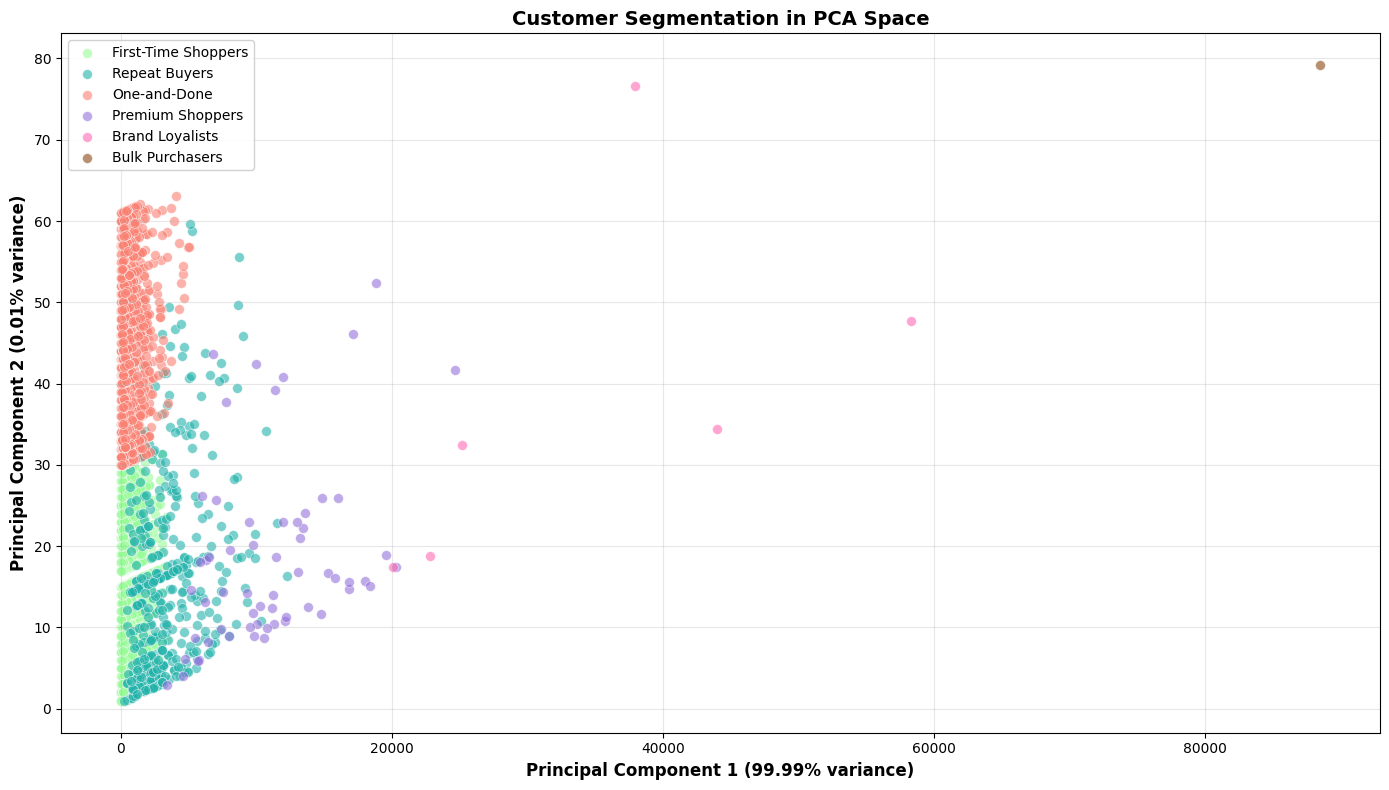

In [ ]:
# VISUALIZE PCA RESULTS

import matplotlib.pyplot as plt
import seaborn as sns

# Use the sample you already created
print(f"Visualizing {len(pca_sample):,} customers (1% sample)\n")

# Create scatter plot
plt.figure(figsize=(14, 8))

# Color map for segments
colors = {
    'VIP': '#FFD700',           # Gold
    'Loyal': '#4169E1',         # Blue
    'At-Risk': '#DC143C',       # Red
    'New Customer': '#32CD32',  # Green
    'Occasional': '#808080',    # Gray
    'Brand Loyalists': '#FF69B4',
    'Bulk Purchasers': '#8B4513',
    'Premium Shoppers': '#9370DB',
    'Repeat Buyers': '#20B2AA',
    'First-Time Shoppers': '#98FB98',
    'One-and-Done': '#FA8072'
}

# Plot each segment
for segment in pca_sample['segment'].unique():
    data = pca_sample[pca_sample['segment'] == segment]
    plt.scatter(
        data['pca_1'],
        data['pca_2'],
        c=colors.get(segment, '#000000'),
        label=segment,
        alpha=0.6,
        s=50,
        edgecolors='white',
        linewidth=0.5
    )

plt.xlabel('Principal Component 1 (99.99% variance)', fontsize=12, fontweight='bold')
plt.ylabel('Principal Component 2 (0.01% variance)', fontsize=12, fontweight='bold')
plt.title('Customer Segmentation in PCA Space', fontsize=14, fontweight='bold')
plt.legend(loc='best', framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# GRADIENT BOOSTED TREES - Predict Repeat Purchases

from pyspark.ml.classification import GBTClassifier
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

# Step 1: Create labels (will customer buy again in 30 days?)
from pyspark.sql.window import Window

# Get time between purchases
purchase_timeline = (
    purchases
    .select("user_id", "event_time")
    .withColumn(
        "next_purchase",
        F.lead("event_time").over(Window.partitionBy("user_id").orderBy("event_time"))
    )
    .withColumn(
        "days_to_next",
        F.datediff("next_purchase", "event_time")
    )
)

# Label customers: 1 = will repurchase within 30 days, 0 = won't
customer_labels = (
    purchase_timeline
    .groupBy("user_id")
    .agg(
        F.min("days_to_next").alias("min_days_between_purchases")
    )
    .withColumn(
        "will_repurchase_30d",
        F.when(F.col("min_days_between_purchases") <= 30, 1).otherwise(0)
    )
)

# Join with RFM features
training_data = (
    rfm
    .join(customer_labels, on="user_id")
    .select("user_id", "recency", "frequency", "monetary", "will_repurchase_30d")
)

print(f"Training data prepared: {training_data.count():,} customers")

# Step 2: Prepare features
feature_assembler = VectorAssembler(
    inputCols=["recency", "frequency", "monetary"],
    outputCol="features"
)

ml_data = feature_assembler.transform(training_data)

# Step 3: Split train/test
train, test = ml_data.randomSplit([0.8, 0.2], seed=42)
print(f"   Train: {train.count():,} | Test: {test.count():,}")

# Step 4: Train GBT model
gbt = GBTClassifier(
    featuresCol="features",
    labelCol="will_repurchase_30d",
    maxIter=10,
    maxDepth=5,
    seed=42
)

print("\n Training Gradient Boosted Trees...")
gbt_model = gbt.fit(train)
print("Model trained!")

# Step 5: Make predictions
predictions = gbt_model.transform(test)

# Step 6: Evaluate
evaluator = BinaryClassificationEvaluator(labelCol="will_repurchase_30d")
auc = evaluator.evaluate(predictions)

accuracy_eval = MulticlassClassificationEvaluator(
    labelCol="will_repurchase_30d",
    predictionCol="prediction",
    metricName="accuracy"
)
accuracy = accuracy_eval.evaluate(predictions)

print(f"\n Model Performance:")
print(f"   AUC: {auc:.4f}")
print(f"   Accuracy: {accuracy:.4f}")

# Show sample predictions
print("\n sample Predictions:")
predictions.select("user_id", "recency", "frequency", "monetary",
                   "will_repurchase_30d", "prediction", "probability").show(10, truncate=False)

# Save model
gbt_model.write().overwrite().save("/kaggle/working/gbt_repurchase_model")
predictions.write.mode("overwrite").parquet("/kaggle/working/gbt_predictions.parquet")
print("\n Saved GBT model and predictions")

📊 Training data prepared: 697,470 customers
   Train: 557,848 | Test: 139,622

🌳 Training Gradient Boosted Trees...
✅ Model trained!

📊 Model Performance:
   AUC: 0.9970
   Accuracy: 0.9841

🔮 Sample Predictions:
+---------+-------+---------+--------+-------------------+----------+----------------------------------------+
|user_id  |recency|frequency|monetary|will_repurchase_30d|prediction|probability                             |
+---------+-------+---------+--------+-------------------+----------+----------------------------------------+
|264649825|56     |2        |1240.04 |1                  |1.0       |[0.06587782434721728,0.9341221756527827]|
|296197073|1      |2        |61.52   |1                  |1.0       |[0.17531325917066165,0.8246867408293383]|
|304707635|18     |1        |2007.52 |0                  |0.0       |[0.934122175652811,0.06587782434718903] |
|319912063|11     |1        |66.9    |0                  |0.0       |[0.9341221756528107,0.06587782434718925]|
|369801696

In [ ]:
# GRADIENT BOOSTED TREES - Predict Repeat Purchases

from pyspark.ml.classification import GBTClassifier
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

# Create labels
from pyspark.sql.window import Window

# Get time between purchases
purchase_timeline = (
    purchases
    .select("user_id", "event_time")
    .withColumn(
        "next_purchase",
        F.lead("event_time").over(Window.partitionBy("user_id").orderBy("event_time"))
    )
    .withColumn(
        "days_to_next",
        F.datediff("next_purchase", "event_time")
    )
)

# Label customers: 1 = will repurchase within 30 days, 0 = will not
customer_labels = (
    purchase_timeline
    .groupBy("user_id")
    .agg(
        F.min("days_to_next").alias("min_days_between_purchases")
    )
    .withColumn(
        "will_repurchase_30d",
        F.when(F.col("min_days_between_purchases") <= 30, 1).otherwise(0)
    )
)

In [ ]:
# Join with RFM features
training_data = (
    rfm
    .join(customer_labels, on="user_id")
    .select("user_id", "recency", "frequency", "monetary", "will_repurchase_30d")
)

print(f"Training data prepared: {training_data.count():,} customers")

# Prepare features
feature_assembler = VectorAssembler(
    inputCols=["recency", "frequency", "monetary"],
    outputCol="features"
)

ml_data = feature_assembler.transform(training_data)

# Split train/test
train, test = ml_data.randomSplit([0.8, 0.2], seed=42)
print(f"   Train: {train.count():,} | Test: {test.count():,}")

Training data prepared: 697,470 customers
   Train: 557,848 | Test: 139,622


In [ ]:
# Train GBT model
gbt = GBTClassifier(
    featuresCol="features",
    labelCol="will_repurchase_30d",
    maxIter=10,
    maxDepth=5,
    seed=42
)

print("Training Gradient Boosted Trees...")
gbt_model = gbt.fit(train)
print("Model trained!")

# Make predictions
predictions = gbt_model.transform(test)

# Evaluate
evaluator = BinaryClassificationEvaluator(labelCol="will_repurchase_30d")
auc = evaluator.evaluate(predictions)

accuracy_eval = MulticlassClassificationEvaluator(
    labelCol="will_repurchase_30d",
    predictionCol="prediction",
    metricName="accuracy"
)
accuracy = accuracy_eval.evaluate(predictions)

print(f"Model Performance:")
print(f"AUC: {auc:.4f}")
print(f"Accuracy: {accuracy:.4f}")

# Show sample predictions
print("Sample Predictions:")
predictions.select("user_id", "recency", "frequency", "monetary",
                   "will_repurchase_30d", "prediction", "probability").show(10, truncate=False)

Training Gradient Boosted Trees...
Model trained!
Model Performance:
AUC: 0.9970
Accuracy: 0.9841
Sample Predictions:
+---------+-------+---------+--------+-------------------+----------+----------------------------------------+
|user_id  |recency|frequency|monetary|will_repurchase_30d|prediction|probability                             |
+---------+-------+---------+--------+-------------------+----------+----------------------------------------+
|264649825|56     |2        |1240.04 |1                  |1.0       |[0.06587782434721728,0.9341221756527827]|
|296197073|1      |2        |61.52   |1                  |1.0       |[0.17531325917066165,0.8246867408293383]|
|304707635|18     |1        |2007.52 |0                  |0.0       |[0.934122175652811,0.06587782434718903] |
|319912063|11     |1        |66.9    |0                  |0.0       |[0.9341221756528107,0.06587782434718925]|
|369801696|18     |3        |3180.19 |1                  |1.0       |[0.06587782434721441,0.9341221756527

=== Hourly Traffic Summary ===
+----+------------+-------+------+---------+---------------+
|hour|total_events|views  |carts |purchases|conversion_rate|
+----+------------+-------+------+---------+---------------+
|0   |755539      |729308 |20460 |5771     |0.79           |
|1   |1402424     |1350441|42242 |9741     |0.72           |
|2   |2745296     |2632243|87929 |25124    |0.95           |
|3   |3949563     |3740363|153230|55970    |1.5            |
|4   |4982552     |4692790|204527|85235    |1.82           |
|5   |5569872     |5234702|233738|101432   |1.94           |
|6   |5823993     |5468082|246479|109432   |2.0            |
|7   |5920460     |5555772|252577|112111   |2.02           |
|8   |6079148     |5701665|257025|120458   |2.11           |
|9   |6005441     |5624290|254534|126617   |2.25           |
|10  |5924965     |5552230|251789|120946   |2.18           |
|11  |5776755     |5421757|243416|111582   |2.06           |
|12  |5726176     |5398504|224527|103145   |1.91      

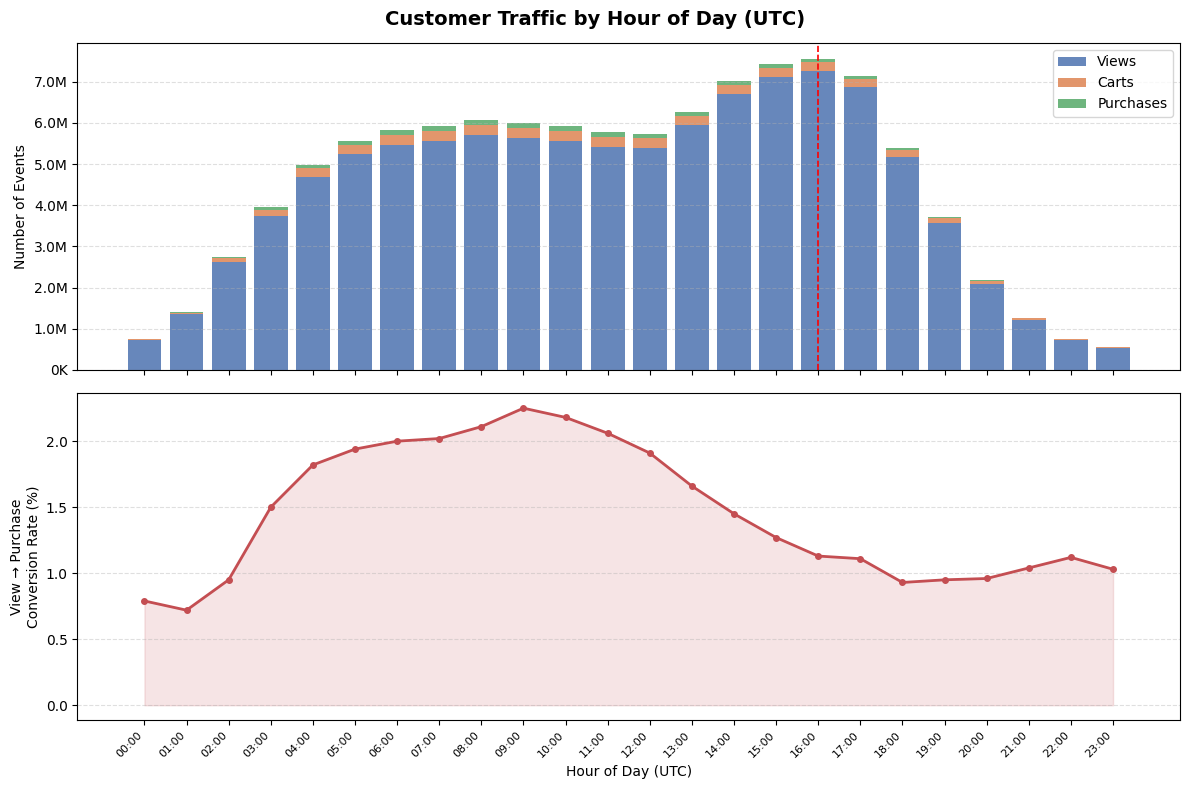

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Extract hour from event_time and count all events per hour

hourly_traffic = (
    ecommerce_df
    .withColumn("hour", F.hour("event_time"))
    .groupBy("hour")
    .agg(
        F.count("*").alias("total_events"),
        F.sum(F.when(F.col("event_type") == "view",     1).otherwise(0)).alias("views"),
        F.sum(F.when(F.col("event_type") == "cart",     1).otherwise(0)).alias("carts"),
        F.sum(F.when(F.col("event_type") == "purchase", 1).otherwise(0)).alias("purchases"),
    )
    .withColumn(
        "conversion_rate",
        F.round(F.col("purchases") / F.col("views") * 100, 2)
    )
    .orderBy("hour")
)

print("=== Hourly Traffic Summary ===")
hourly_traffic.show(24, truncate=False)

# determining peak hours
peak_hour = hourly_traffic.orderBy(F.desc("total_events")).first()
peak_purchase_hour = hourly_traffic.orderBy(F.desc("purchases")).first()
best_conversion_hour = hourly_traffic.orderBy(F.desc("conversion_rate")).first()

print(f"Peak traffic hour:       {peak_hour['hour']:02d}:00  ({peak_hour['total_events']:,} events)")
print(f"Peak purchase hour:      {peak_purchase_hour['hour']:02d}:00  ({peak_purchase_hour['purchases']:,} purchases)")
print(f"Best conversion hour:    {best_conversion_hour['hour']:02d}:00  ({best_conversion_hour['conversion_rate']}% view→purchase)")

# plotting results
df_pd = hourly_traffic.toPandas().sort_values("hour")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
fig.suptitle("Customer Traffic by Hour of Day (UTC)", fontsize=14, fontweight="bold")

hours = df_pd["hour"]

# Top panel: event volume stacked bar
ax1.bar(hours, df_pd["views"],     label="Views",     color="#4C72B0", alpha=0.85)
ax1.bar(hours, df_pd["carts"],     label="Carts",     color="#DD8452", alpha=0.85, bottom=df_pd["views"])
ax1.bar(hours, df_pd["purchases"], label="Purchases", color="#55A868", alpha=0.85,
        bottom=df_pd["views"] + df_pd["carts"])
ax1.set_ylabel("Number of Events")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K"))
ax1.legend()
ax1.grid(axis="y", linestyle="--", alpha=0.4)
ax1.axvline(peak_hour["hour"], color="red", linestyle="--", linewidth=1.2, label=f"Peak hour ({peak_hour['hour']:02d}:00)")

# Bottom panel: conversion rate line
ax2.plot(hours, df_pd["conversion_rate"], color="#C44E52", linewidth=2, marker="o", markersize=4)
ax2.fill_between(hours, df_pd["conversion_rate"], alpha=0.15, color="#C44E52")
ax2.set_xlabel("Hour of Day (UTC)")
ax2.set_ylabel("View → Purchase\nConversion Rate (%)")
ax2.set_xticks(range(0, 24))
ax2.set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45, ha="right", fontsize=8)
ax2.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
plt.savefig("IST418_graph1.pdf", bbox_inches="tight") # save graph as pdf

<Figure size 640x480 with 0 Axes>

GRAPHS:

In [ ]:

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import numpy as np
from pyspark.sql import Window
from pyspark.sql.functions import date_format

# COLOR PALLETE
COLORS = {
    "VIP":          "#2196F3",   # blue
    "New Customer": "#4CAF50",   # green
    "At-Risk":      "#F44336",   # red
    "overall":      "#7B68EE",   # medium slate blue
}
SEGMENT_ORDER = ["VIP", "New Customer", "At-Risk"]

plt.rcParams.update({
    "font.family":  "sans-serif",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.titlesize":    11,
    "axes.labelsize":    9,
    "xtick.labelsize":   8,
    "ytick.labelsize":   8,
})


In [ ]:
# DATA PREP

# Hourly traffic (overall)
hourly_overall = (
    ecommerce_df
    .withColumn("hour", F.hour("event_time"))
    .groupBy("hour")
    .agg(
        F.count("*").alias("total_events"),
        F.sum(F.when(F.col("event_type") == "view",     1).otherwise(0)).alias("views"),
        F.sum(F.when(F.col("event_type") == "cart",     1).otherwise(0)).alias("carts"),
        F.sum(F.when(F.col("event_type") == "purchase", 1).otherwise(0)).alias("purchases"),
    )
    .withColumn("conversion_rate",
                F.round(F.col("purchases") / F.col("views") * 100, 2))
    .orderBy("hour")
    .toPandas()
)

# Hourly purchases by segment
hourly_seg = (
    purchases
    .join(rfm_final.select("user_id", "segment"), on="user_id")
    .withColumn("hour", F.hour("event_time"))
    .groupBy("segment", "hour")
    .agg(
        F.count("*").alias("purchases"),
        F.round(F.sum("price"), 2).alias("revenue"),
    )
    .orderBy("hour")
    .toPandas()
)

# Top 10 overall product categories
top_cats_overall = (
    purchases
    .filter(F.col("category_code").isNotNull())
    .withColumn("top_cat", F.split(F.col("category_code"), r"\.").getItem(0))
    .groupBy("top_cat")
    .agg(F.count("*").alias("purchase_count"),
         F.round(F.sum("price"), 2).alias("revenue"))
    .orderBy(F.desc("purchase_count"))
    .limit(10)
    .toPandas()
)

# Top 8 categories per segment
top_cats_seg = (
    purchases
    .join(rfm_final.select("user_id", "segment"), on="user_id")
    .filter(F.col("category_code").isNotNull())
    .withColumn("top_cat", F.split(F.col("category_code"), r"\.").getItem(0))
    .groupBy("segment", "top_cat")
    .agg(F.count("*").alias("purchase_count"),
         F.round(F.sum("price"), 2).alias("revenue"))
    .withColumn("rank", F.row_number().over(
        Window.partitionBy("segment").orderBy(F.desc("purchase_count"))))
    .filter(F.col("rank") <= 8)
    .orderBy("segment", "rank")
    .toPandas()
)

# Monthly trends by segment
monthly_seg = (
    purchases
    .join(rfm_final.select("user_id", "segment"), on="user_id")
    .withColumn("month", date_format("event_time", "yyyy-MM"))
    .groupBy("segment", "month")
    .agg(F.count("*").alias("purchases"),
         F.round(F.sum("price"), 2).alias("revenue"))
    .orderBy("month", "segment")
    .toPandas()
)

# Revenue & customer counts per segment
rev_share = (
    rfm_final
    .groupBy("segment")
    .agg(F.count("*").alias("customers"),
         F.round(F.sum("monetary"), 2).alias("revenue"),
         F.round(F.mean("monetary"), 2).alias("avg_rev"),
         F.round(F.mean("recency"),  1).alias("avg_recency"),
         F.round(F.mean("frequency"),2).alias("avg_frequency"))
    .withColumn("rev_pct",
                F.round(F.col("revenue") /
                        F.sum("revenue").over(Window.partitionBy()) * 100, 1))
    .toPandas()
    .set_index("segment")
)

SEGMENTS = ["VIP", "New Customer", "At-Risk"]

In [ ]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Create folder if it doesn't exist
shared_folder = '/content/drive/MyDrive/IST418_Project_Data/'
os.makedirs(shared_folder, exist_ok=True)

# Save all your dataframes
print("Saving data to Google Drive...\n")

ecommerce_df.write.mode('overwrite').parquet(f"{shared_folder}ecommerce_df.parquet")
print("Saved ecommerce_df")

purchases.write.mode('overwrite').parquet(f"{shared_folder}purchases.parquet")
print("Saved purchases")

rfm_df.write.mode('overwrite').parquet(f"{shared_folder}rfm_df.parquet")
print("Saved rfm_df")

rfm_segments.write.mode('overwrite').parquet(f"{shared_folder}rfm_segments.parquet")
print("Saved rfm_segments")

print("\nAll data saved to Google Drive!")
print(f"Location: {shared_folder}")

Searching for parquet files...

📁 Found in /kaggle/working/:
   - purchases.parquet (0.02 MB)
   - top_categories.parquet (0.00 MB)
   - cluster_profiles.parquet (0.00 MB)
   - revenue_analysis.parquet (0.00 MB)
   - ecommerce_df.parquet (0.03 MB)
   - rfm_segments.parquet (0.04 MB)
   - rfm.parquet (0.05 MB)



In [ ]:
from google.colab import drive
import shutil
import os

# Mount Google Drive
print("🔗 Connecting to Google Drive...")
drive.mount('/content/drive')

# Create destination folder in Google Drive
drive_folder = '/content/drive/MyDrive/IST418_Project_Data/'
os.makedirs(drive_folder, exist_ok=True)

# Source folder (where your Kaggle files are)
source_folder = '/kaggle/working/'

# List of your parquet files/directories
parquet_items = [
    'purchases.parquet',
    'top_categories.parquet',
    'cluster_profiles.parquet',
    'revenue_analysis.parquet',
    'ecommerce_df.parquet',
    'rfm_segments.parquet',
    'rfm.parquet'
]

print(f"\n Transferring {len(parquet_items)} parquet directories to Google Drive...\n")

for item in parquet_items:
    source_path = os.path.join(source_folder, item)
    dest_path = os.path.join(drive_folder, item)

    if os.path.exists(source_path):
        # Get size of directory
        total_size = sum(
            os.path.getsize(os.path.join(dirpath, filename))
            for dirpath, dirnames, filenames in os.walk(source_path)
            for filename in filenames
        )
        size_mb = total_size / (1024 * 1024)

        print(f"Copying: {item} ({size_mb:.2f} MB)")

        # Remove destination if it exists, then copy
        if os.path.exists(dest_path):
            shutil.rmtree(dest_path)
        shutil.copytree(source_path, dest_path)
    else:
        print(f"Not found: {item}")

print(f" All parquet directories transferred to Google Drive!")
print(f"Location: {drive_folder}")
print(f"Next step: Share the 'IST418_Project_Data' folder with your groupmates!")

🔗 Connecting to Google Drive...


MessageError: Error: credential propagation was unsuccessful

✅ Saved: segment_bar_chart_clean.pdf


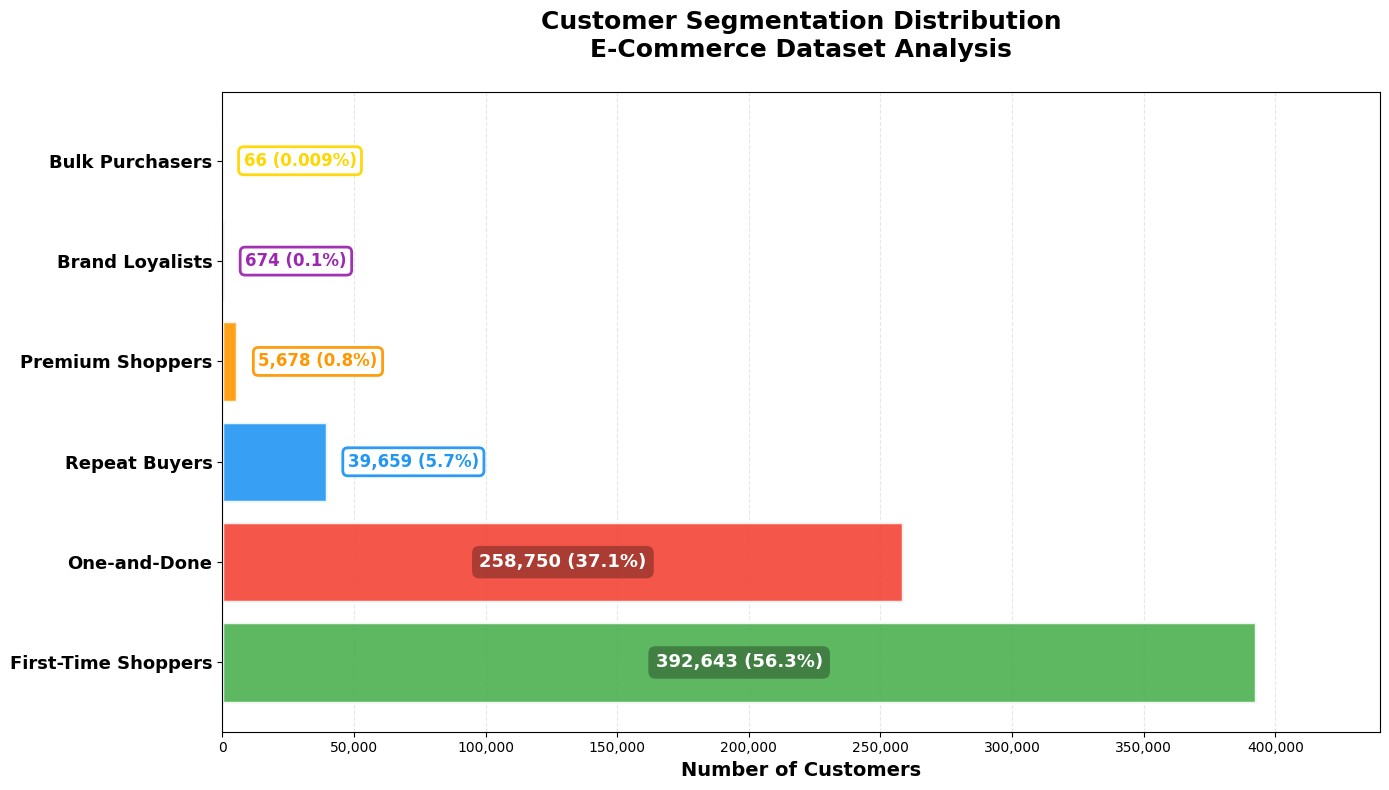

In [ ]:
# HORIZONTAL BAR CHART - Customer Segmentation (Updated)

import matplotlib.pyplot as plt
import numpy as np

# Data
segments = ['First-Time Shoppers', 'One-and-Done', 'Repeat Buyers',
            'Premium Shoppers', 'Brand Loyalists', 'Bulk Purchasers']
counts = [392643, 258750, 39659, 5678, 674, 66]
percentages = [56.3, 37.1, 5.7, 0.8, 0.1, 0.009]
colors = ['#4CAF50', '#F44336', '#2196F3', '#FF9800', '#9C27B0', '#FFD700']

# Create figure
fig, ax = plt.subplots(figsize=(14, 8))

# Create horizontal bars
y_pos = np.arange(len(segments))
bars = ax.barh(y_pos, counts, color=colors, alpha=0.9,
               edgecolor='white', linewidth=2.5)

# Add labels
for i, (bar, count, pct) in enumerate(zip(bars, counts, percentages)):
    width = bar.get_width()

    # First-Time Shoppers and One-and-Done - label inside (big bars)
    if i <= 1:
        label = f'{count:,} ({pct}%)'
        ax.text(width / 2, bar.get_y() + bar.get_height() / 2,
                label, ha='center', va='center',
                fontsize=13, fontweight='bold', color='white',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='black',
                         alpha=0.3, edgecolor='none'))

    # All others - label outside to the right
    else:
        label = f'{count:,} ({pct}%)'
        ax.text(width + 8000, bar.get_y() + bar.get_height() / 2,
                label, ha='left', va='center',
                fontsize=12, fontweight='bold', color=colors[i],
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                         edgecolor=colors[i], linewidth=2, alpha=0.95))

# Format axes
ax.set_yticks(y_pos)
ax.set_yticklabels(segments, fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Customers', fontsize=14, fontweight='bold')
ax.set_title('Customer Segmentation Distribution\nE-Commerce Dataset Analysis',
             fontsize=18, fontweight='bold', pad=25)

# Format x-axis with commas
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Add grid
ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.8)
ax.set_axisbelow(True)

# Extend x-axis to make room for outside labels
ax.set_xlim(0, max(counts) * 1.12)

plt.tight_layout()
plt.savefig('segment_bar_chart_clean.pdf', dpi=300, bbox_inches='tight')
print("✅ Saved: segment_bar_chart_clean.pdf")
plt.show()

✅ Saved: revenue_treemap.pdf


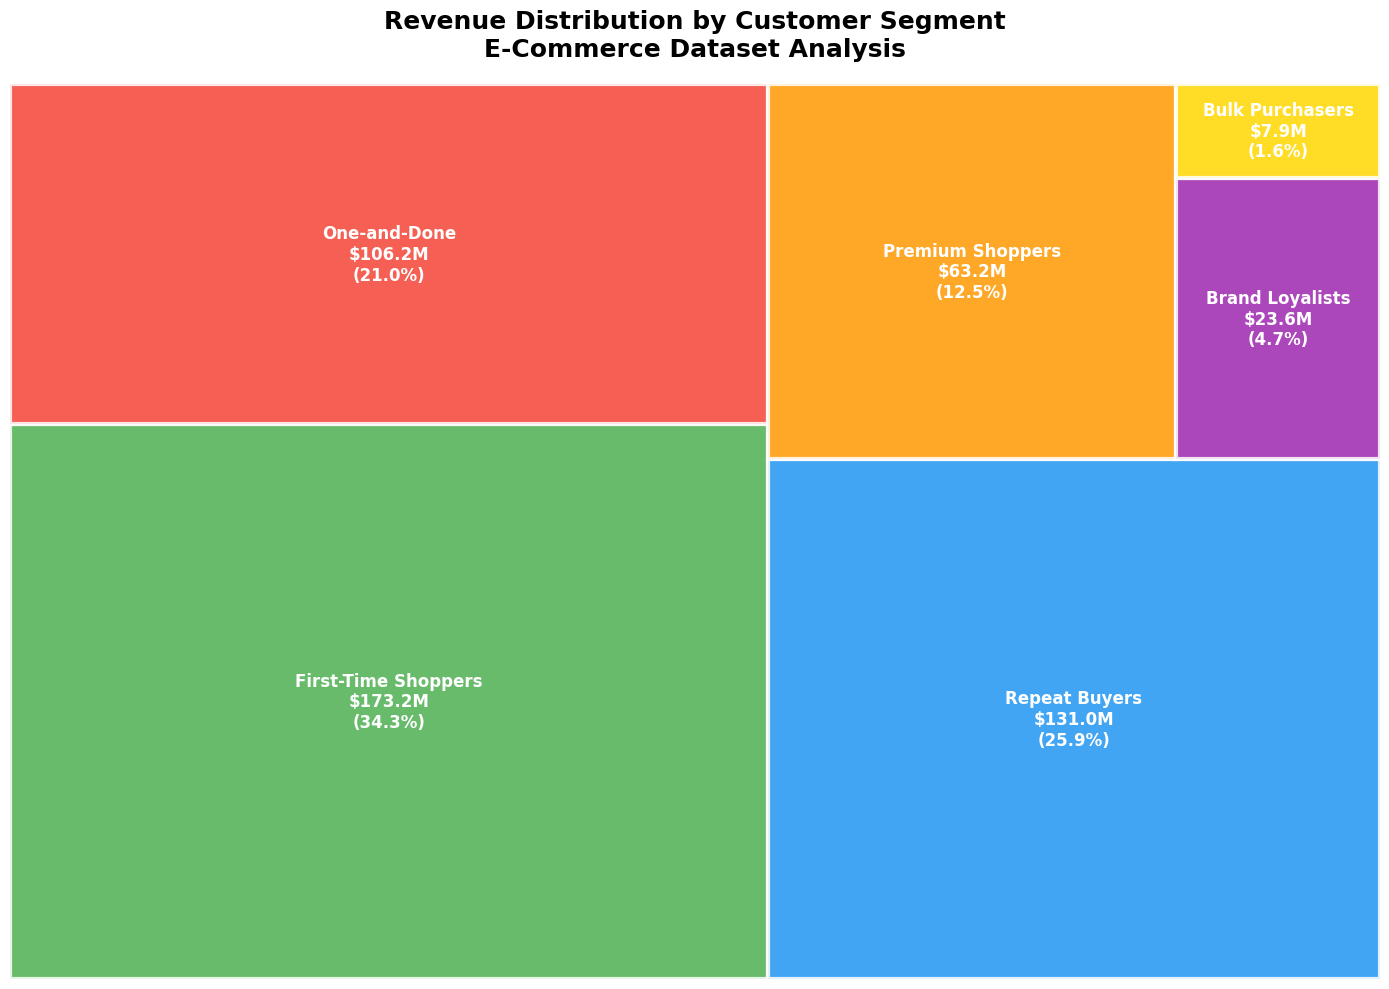

In [ ]:
import matplotlib.pyplot as plt
import squarify  # You may need to install: pip install squarify

# Data from your Code Summary
segments = ['First-Time Shoppers', 'One-and-Done', 'Repeat Buyers',
            'Premium Shoppers', 'Brand Loyalists', 'Bulk Purchasers']

revenue_millions = [173.2, 106.2, 131.0, 63.2, 23.6, 7.9]
revenue_percentages = [34.29, 21.02, 25.94, 12.52, 4.67, 1.56]

# Colors matching your other charts
colors = ['#4CAF50', '#F44336', '#2196F3', '#FF9800', '#9C27B0', '#FFD700']

# Create labels with revenue and percentage
labels = [f"{seg}\n${rev:.1f}M\n({pct:.1f}%)"
          for seg, rev, pct in zip(segments, revenue_millions, revenue_percentages)]

# Create figure
fig, ax = plt.subplots(figsize=(14, 10))

# Create treemap
squarify.plot(sizes=revenue_millions,
              label=labels,
              color=colors,
              alpha=0.85,
              text_kwargs={'fontsize': 12, 'fontweight': 'bold', 'color': 'white'},
              edgecolor='white',
              linewidth=3,
              ax=ax)

# Title
ax.set_title('Revenue Distribution by Customer Segment\nE-Commerce Dataset Analysis',
             fontsize=18, fontweight='bold', pad=20)

# Remove axes
ax.axis('off')

plt.tight_layout()
plt.savefig('revenue_treemap.pdf', dpi=300, bbox_inches='tight')
print("✅ Saved: revenue_treemap.pdf")
plt.show()

In [ ]:
! pip install squarify

In [ ]:
from google.colab import files

In [ ]:
files.download('revenue_treemap.pdf')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Saved: heatmap_percentage_counts.pdf


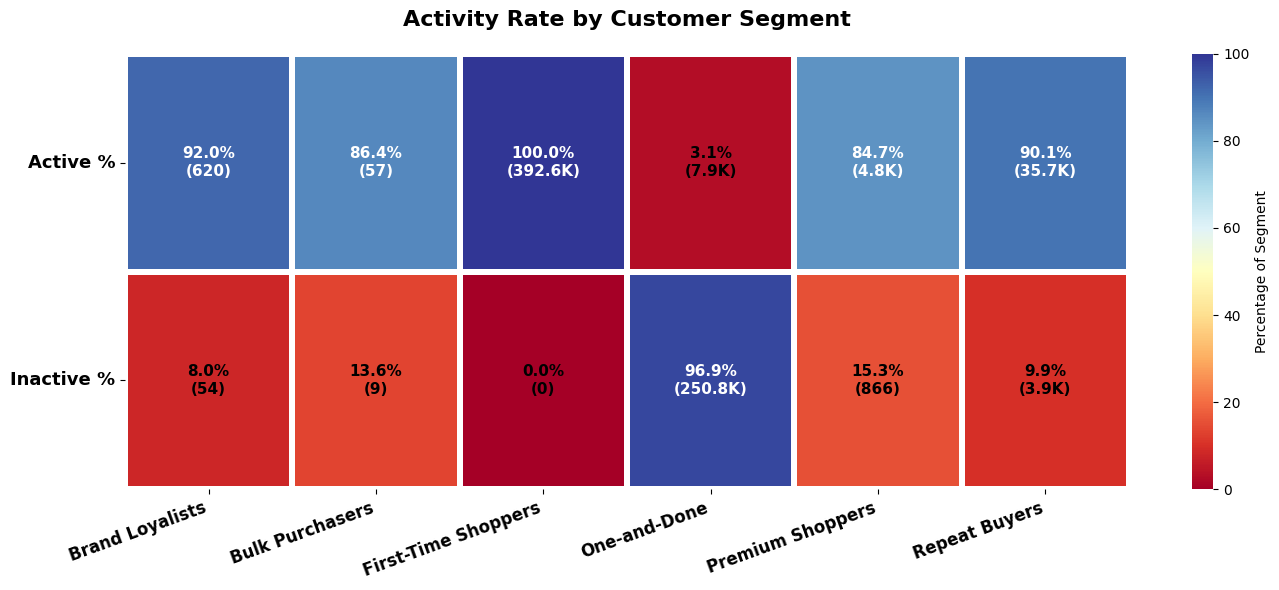

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

# Data from your screenshot
segments = ['Brand Loyalists', 'Bulk Purchasers', 'First-Time Shoppers',
            'One-and-Done', 'Premium Shoppers', 'Repeat Buyers']

# Active and Inactive counts
active_counts = [620, 57, 392643, 7949, 4812, 35746]
inactive_counts = [54, 9, 0, 250801, 866, 3913]

# Calculate percentages
totals = [a + i for a, i in zip(active_counts, inactive_counts)]
active_pct = [(a / t * 100) if t > 0 else 0 for a, t in zip(active_counts, totals)]
inactive_pct = [(i / t * 100) if t > 0 else 0 for i, t in zip(inactive_counts, totals)]

# Calculate percentages
totals = [a + i if (a + i) > 0 else 1 for a, i in zip(active_counts, inactive_counts)]
active_pct = [(a / t * 100) for a, t in zip(active_counts, totals)]
inactive_pct = [(i / t * 100) for a, i, t in zip(active_counts, inactive_counts, totals)]

# Create percentage matrix
data_pct = np.array([active_pct, inactive_pct])

fig, ax = plt.subplots(figsize=(14, 6))

# Create heatmap with better contrast
sns.heatmap(data_pct, annot=False, cmap='RdYlBu',
            xticklabels=segments, yticklabels=['Active %', 'Inactive %'],
            cbar_kws={'label': 'Percentage of Segment'},
            linewidths=3, linecolor='white',
            vmin=0, vmax=100, ax=ax, center=50)

# Add custom annotations with both percentage AND count
for i in range(2):
    for j in range(len(segments)):
        pct = data_pct[i, j]
        count = active_counts[j] if i == 0 else inactive_counts[j]

        if count < 1000:
            count_str = f'{count}'
        else:
            count_str = f'{count/1000:.1f}K'

        text_val = f'{pct:.1f}%\n({count_str})'

        # Color based on percentage
        if pct > 50:
            color = 'white'
        else:
            color = 'black'

        ax.text(j + 0.5, i + 0.5, text_val,
               ha='center', va='center', fontsize=11, fontweight='bold',
               color=color)

ax.set_xticklabels(segments, fontsize=12, fontweight='bold', rotation=20, ha='right')
ax.set_yticklabels(['Active %', 'Inactive %'], fontsize=13, fontweight='bold', rotation=0)

ax.set_title('Activity Rate by Customer Segment',
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('heatmap_percentage_counts.pdf', dpi=300, bbox_inches='tight')
print("✅ Saved: heatmap_percentage_counts.pdf")
plt.show()
plt.show()

🎯 Creating Strategic Frequency Impact Chart...

📊 Average Retention Rate: 92.8%
📊 Frequency=1: 0.0% | Frequency=2: 92.0%



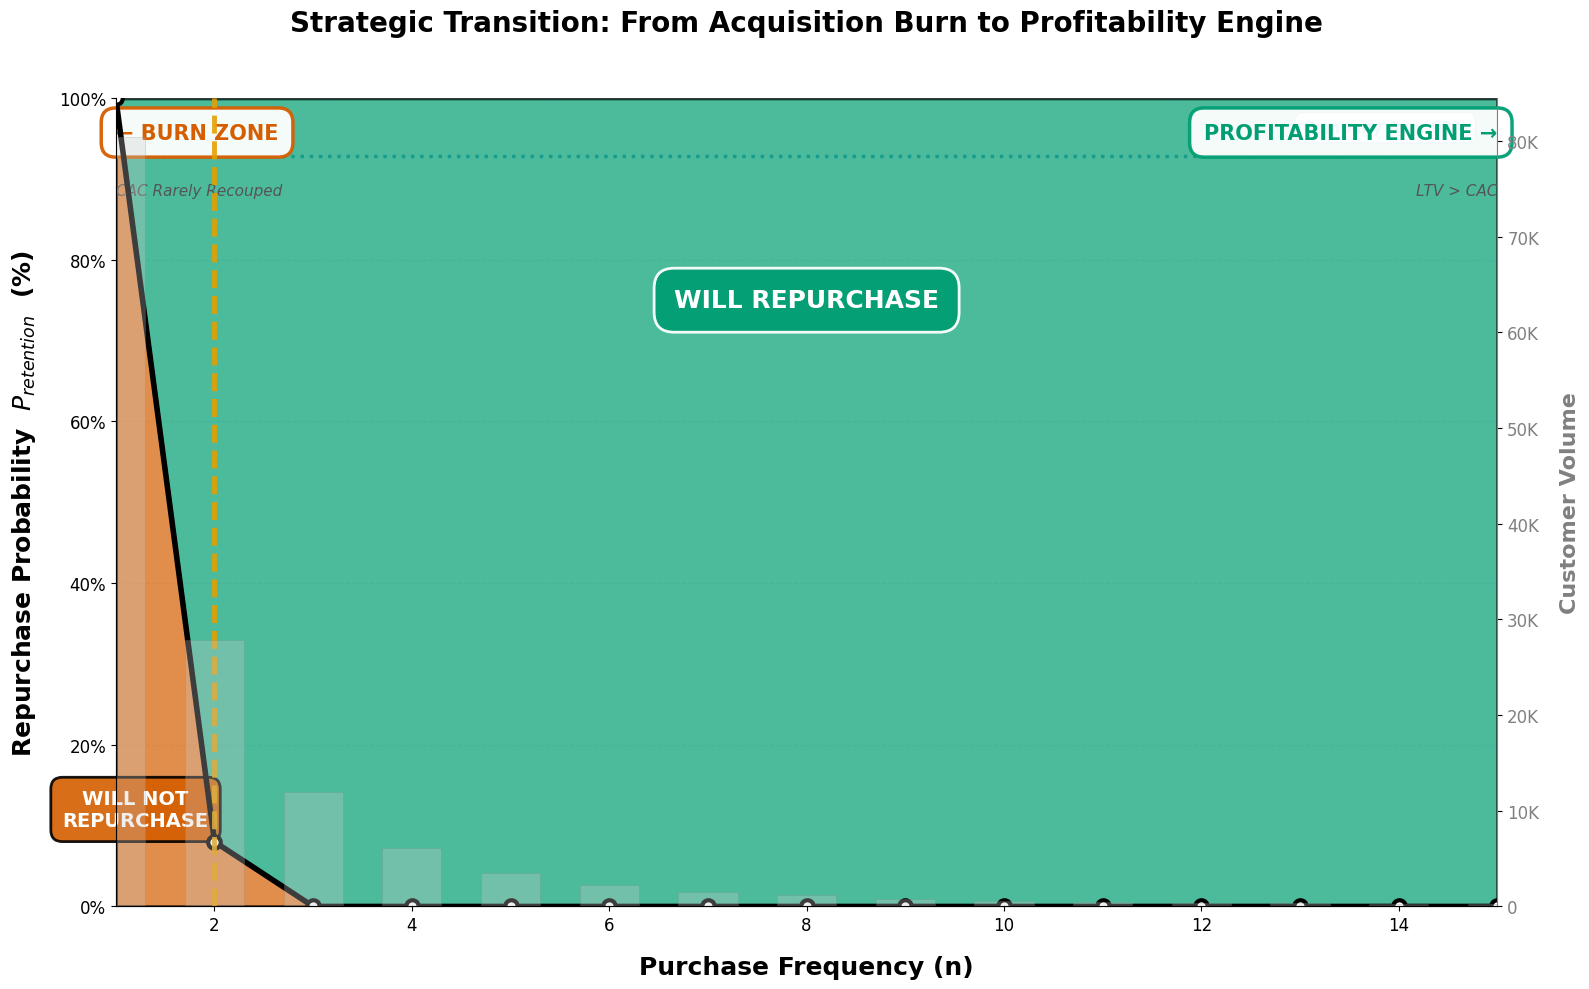

✅ Chart saved: Strategic_Frequency_Analysis.pdf

📊 Strategic Insights:
   • Burn Zone (1 purchase): 0% retention | Volume: 80,470
   • Profitability Engine (2+ purchases): 92%+ retention
   • Gap vs Average: -1 percentage points
   • ROI Multiplier: infx increase



/tmp/ipykernel_10515/993850802.py:168: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"   • ROI Multiplier: {rate_2/rate_1:.1f}x increase\n")


In [ ]:
# STRATEGIC FREQUENCY IMPACT CHART

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pyspark.sql import functions as F
import numpy as np

print("Creating Strategic Frequency Impact Chart...\n")

# Calculate repurchase rate by frequency
freq_analysis = (
    predictions
    .select("user_id", "will_repurchase_30d")
    .join(training_data.select("user_id", F.col("frequency").alias("purchase_count")), on="user_id")
    .groupBy("purchase_count")
    .agg(
        F.count("*").alias("total_customers"),
        F.sum(F.when(F.col("will_repurchase_30d") == 1, 1).otherwise(0)).alias("repurchasers")
    )
    .withColumn("repurchase_rate", F.round((F.col("repurchasers") / F.col("total_customers")) * 100, 1))
    .orderBy("purchase_count")
    .toPandas()
)

freq_df = freq_analysis.rename(columns={'purchase_count': 'frequency'})
freq_df = freq_df[freq_df['frequency'] <= 15]
freq_df['wont_repurchase'] = 100 - freq_df['repurchase_rate']

# Calculate average retention rate
avg_retention = freq_df['repurchase_rate'].mean()

# Get key values
rate_1 = freq_df[freq_df['frequency'] == 1]['repurchase_rate'].values[0]
rate_2 = freq_df[freq_df['frequency'] == 2]['repurchase_rate'].values[0]

print(f"Average Retention Rate: {avg_retention:.1f}%")
print(f"Frequency=1: {rate_1:.1f}% | Frequency=2: {rate_2:.1f}%\n")

# Create figure with dual axis
fig, ax1 = plt.subplots(figsize=(16, 10))

# Set clean sans-serif font
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']

# Colorblind-safe palette
BURN_COLOR = '#D55E00'      # Vermillion
ENGINE_COLOR = '#009E73'    # Bluish green
VOLUME_COLOR = '#CCCCCC'    # Light grey for volume bars

ax2 = ax1.twinx()
ax2.bar(freq_df['frequency'], freq_df['total_customers'],
        color=VOLUME_COLOR, alpha=0.3, width=0.6, zorder=1, edgecolor='grey', linewidth=0.5)
ax2.set_ylabel('Customer Volume', fontsize=16, fontweight='bold', color='grey', labelpad=15)
ax2.tick_params(axis='y', labelcolor='grey', labelsize=12)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}K' if x >= 1000 else f'{int(x)}'))
ax2.spines['right'].set_visible(True)
ax2.spines['right'].set_color('grey')

# Stacked area chart
ax1.fill_between(freq_df['frequency'], 0, freq_df['wont_repurchase'],
                color=BURN_COLOR, alpha=0.7, edgecolor='black', linewidth=2.5, zorder=3)
ax1.fill_between(freq_df['frequency'], freq_df['wont_repurchase'], 100,
                color=ENGINE_COLOR, alpha=0.7, edgecolor='black', linewidth=2.5, zorder=3)

# Dividing line
ax1.plot(freq_df['frequency'], freq_df['wont_repurchase'],
        color='black', linewidth=4, marker='o', markersize=9,
        markerfacecolor='white', markeredgewidth=3, markeredgecolor='black', zorder=4)

# Critical transition line at x=2
ax1.axvline(x=2, color='#E69F00', linestyle='--', linewidth=3.5, alpha=0.9, zorder=5)

# Average retention reference line
ax1.axhline(y=avg_retention, color='#0072B2', linestyle=':', linewidth=2.5, alpha=0.7, zorder=2)
ax1.text(freq_df['frequency'].max() * 0.98, avg_retention + 3,
        f'Company Avg: {avg_retention:.0f}%', fontsize=11, ha='right',
        fontweight='bold', color='#0072B2',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='#0072B2'))

# Label inside burn zone - positioned to fit in orange area only
ax1.text(1.2, 12, 'WILL NOT\nREPURCHASE', fontsize=14, fontweight='bold',
        color='white', ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.6', facecolor=BURN_COLOR,
                 edgecolor='black', linewidth=2, alpha=0.9))

# Label inside profitability engine
ax1.text(8, 75, 'WILL REPURCHASE', fontsize=18, fontweight='bold',
        color='white', ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.8', facecolor=ENGINE_COLOR,
                 edgecolor='white', linewidth=2, alpha=0.95))

# Left quadrant - Burn Zone
ax1.text(1, 95, '← BURN ZONE', fontsize=15, fontweight='bold', color=BURN_COLOR, ha='left',
        bbox=dict(boxstyle='round,pad=0.7', facecolor='white', alpha=0.95,
                 edgecolor=BURN_COLOR, linewidth=2.5))
ax1.text(1, 88, 'CAC Rarely Recouped', fontsize=11, ha='left', style='italic', color='#555')

# Right quadrant - Profitability Engine
ax1.text(freq_df['frequency'].max(), 95, 'PROFITABILITY ENGINE →',
        fontsize=15, fontweight='bold', color=ENGINE_COLOR, ha='right',
        bbox=dict(boxstyle='round,pad=0.7', facecolor='white', alpha=0.95,
                 edgecolor=ENGINE_COLOR, linewidth=2.5))
ax1.text(freq_df['frequency'].max(), 88, 'LTV > CAC',
        fontsize=11, ha='right', style='italic', color='#555')

# Despine
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Labels with LaTeX-style notation
ax1.set_xlabel('Purchase Frequency (n)', fontsize=18, fontweight='bold', labelpad=15)
ax1.set_ylabel('Repurchase Probability  $P_{retention}$  (%)',
              fontsize=18, fontweight='bold', labelpad=15)

# Title with strategic framing
gap = rate_2 - avg_retention
ax1.set_title(
    f'Strategic Transition: From Acquisition Burn to Profitability Engine\n',
    fontsize=20, fontweight='bold', pad=25
)

ax1.set_ylim([0, 100])
ax1.set_xlim([1, freq_df['frequency'].max()])
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)}%'))
ax1.tick_params(axis='both', labelsize=12)

# Subtle grid
ax1.grid(axis='y', alpha=0.25, linestyle='--', linewidth=0.8, zorder=0)
ax1.set_axisbelow(True)

plt.tight_layout()
plt.savefig('Strategic_Frequency_Analysis.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f" Chart saved: Strategic_Frequency_Analysis.pdf")
print(f"\ Strategic Insights:")
print(f"   • Burn Zone (1 purchase): {rate_1:.0f}% retention | Volume: {freq_df[freq_df['frequency']==1]['total_customers'].values[0]:,}")
print(f"   • Profitability Engine (2+ purchases): {rate_2:.0f}%+ retention")
print(f"   • Gap vs Average: {gap:.0f} percentage points")
print(f"   • ROI Multiplier: {rate_2/rate_1:.1f}x increase\n")

In [ ]:
files.download('Strategic_Frequency_Analysis.pdf')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>